In [12]:
# PyCIAM output visualizations with xarray and cartopy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# Load the zarr store as xarray Dataset
zarr_path = Path("pyCIAM_outputs.zarr")
ds = xr.open_zarr(zarr_path)
ds = ds.sel(year=ds.year[(ds.year < 2005) | (ds.year > 2014)])
ds

<xarray.Dataset>
Dimensions:       (adm1: 1836, case: 11, costtype: 6, scenario: 5, quantile: 1,
                   year: 86, ssp: 5, iam: 2, seg: 9568)
Coordinates:
  * adm1          (adm1) <U8 'ABW' 'AGO.11_1' 'AGO.16_1' ... 'ZNC.3_1' 'ZNC.4_1'
  * case          (case) <U12 'noAdaptation' 'protect10' ... 'optimalfixed'
  * costtype      (costtype) <U15 'wetland' 'inundation' ... 'stormPopulation'
  * iam           (iam) <U5 'IIASA' 'OECD'
  * quantile      (quantile) float64 0.5
  * scenario      (scenario) <U17 'SSP126' 'SSP245' ... 'ncc_regional_rise'
  * seg           (seg) <U9 'seg_00001' 'seg_00002' ... 'seg_99018' 'seg_99019'
  * ssp           (ssp) <U4 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5'
  * year          (year) int32 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables:
    costs         (case, costtype, adm1, scenario, quantile, year, ssp, iam) float32 dask.array<chunksize=(11, 6, 9, 5, 1, 10, 5, 2), meta=np.ndarray>
    optimal_case  (seg, scenario, quantile, ssp, iam) uint8 dask.array<chunksize=(9568, 5, 1, 5, 2), meta=np.ndarray>
Attributes:
    description:                  pyCIAM run with regional rise SLR data mapp...
    planning_period_start_years:  [2005, 2010, 2020, 2030, 2040, 2050, 2060, ...
    updated:                      Thu Feb 12 16:54:07 2026

In [13]:
ds['costtype']

<xarray.DataArray 'costtype' (costtype: 6)>
array(['wetland', 'inundation', 'relocation', 'protection', 'stormCapital',
       'stormPopulation'], dtype='<U15')
Coordinates:
  * costtype  (costtype) <U15 'wetland' 'inundation' ... 'stormPopulation'
Attributes:
    description:  stormCapital: Value of capital stock lost due to ESL\nstorm...
    long_name:    Cost Category

In [14]:
ds.sel(costtype="relocation", scenario="SSP126").sum('seg')['optimal_case'].values

array([[[169033, 145306],
        [168000, 145919],
        [165215, 146681],
        [163264, 145112],
        [161380, 142694]]], dtype=uint32)

In [ ]:
# Bar plot: total costs by adaptation case and SSP
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(ssp_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, case_name in enumerate(cases.keys()):
    vals = [results[case_name][label] for label in ssp_labels]
    offset = (i - len(cases) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=case_name)

ax.set_xticks(x)
ax.set_xticklabels(ssp_labels)
ax.set_ylabel("Cost ($)")
ax.set_title("Total Costs by Adaptation Case and SSP (2100)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
ssp_indices = [0, 1, 2, 4]
ssp_labels  = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
costtypes   = ['wetland', 'inundation', 'relocation', 'protection', 'stormCapital', 'stormPopulation']

results_by_cost = {}

for idx, label in zip(ssp_indices, ssp_labels):
    cost_by_type = {}
    for ct in costtypes:
        c = (
            ds.costs.sel(case='optimalfixed', costtype=ct, year=2100)
            .isel(scenario=idx, ssp=idx, iam=0, quantile=0)
            .sum(dim='adm1')
            .load()
        )
        cost_by_type[ct] = float(c.values)
    results_by_cost[label] = cost_by_type

# Build dataframe
df_costs = pd.DataFrame(results_by_cost).T
df_costs.columns = costtypes
df_costs['Total'] = df_costs.sum(axis=1)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(df_costs.to_string())

                   wetland         inundation         relocation         protection      stormCapital   stormPopulation                Total
SSP1-2.6 49,756,958,720.00 116,456,816,640.00 174,599,618,560.00 393,147,023,360.00 43,869,257,728.00 60,771,131,392.00   838,600,806,400.00
SSP2-4.5 47,736,619,008.00 120,480,825,344.00 194,578,268,160.00 426,335,600,640.00 48,959,959,040.00 70,557,229,056.00   908,648,501,248.00
SSP3-7.0 31,889,311,744.00  84,853,325,824.00 139,781,881,856.00 403,959,316,480.00 38,931,513,344.00 63,768,584,192.00   763,183,933,440.00
SSP5-8.5 79,841,943,552.00 173,404,192,768.00 281,992,462,336.00 509,314,465,792.00 56,984,109,056.00 85,949,833,216.00 1,187,487,006,720.00


In [11]:
ssp_indices = [0, 1, 2, 4]
ssp_labels  = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
costtypes   = ['wetland', 'inundation', 'relocation', 'protection', 'stormCapital', 'stormPopulation']

results_by_cost = {}

for idx, label in zip(ssp_indices, ssp_labels):
    cost_by_type = {}
    for ct in costtypes:
        c = (
            ds.costs.sel(case='noAdaptation', costtype=ct, year=2100)
            .isel(scenario=idx, ssp=idx, iam=0, quantile=0)
            .sum(dim='adm1')
            .load()
        )
        cost_by_type[ct] = float(c.values)
    results_by_cost[label] = cost_by_type

# Build dataframe
df_costs = pd.DataFrame(results_by_cost).T
df_costs.columns = costtypes
df_costs['Total'] = df_costs.sum(axis=1)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(df_costs.to_string())

                   wetland           inundation           relocation  protection         stormCapital      stormPopulation                 Total
SSP1-2.6 48,305,016,832.00 1,199,411,167,232.00 2,196,839,333,888.00        0.00 2,715,323,990,016.00 3,664,350,019,584.00  9,824,229,527,552.00
SSP2-4.5 46,544,232,448.00   897,190,461,440.00 2,022,581,338,112.00        0.00 2,271,334,105,088.00 3,898,077,085,696.00  9,135,727,222,784.00
SSP3-7.0 31,166,038,016.00   611,919,265,792.00 1,438,468,538,368.00        0.00 1,758,695,784,448.00 4,151,641,112,576.00  7,991,890,739,200.00
SSP5-8.5 77,313,859,584.00 1,914,134,986,752.00 3,888,224,665,600.00        0.00 3,253,659,762,688.00 4,384,252,231,680.00 13,517,585,506,304.00


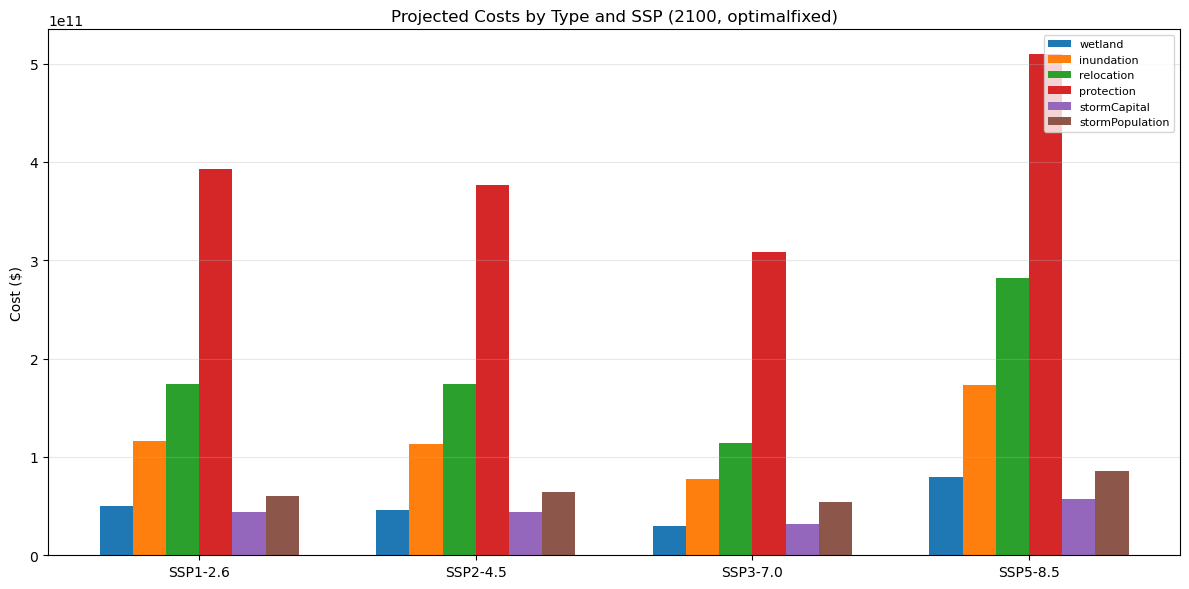

In [8]:
plot_cols = costtypes 
x = np.arange(len(ssp_labels))
width = 0.12

fig, ax = plt.subplots(figsize=(12, 6))
for i, ct in enumerate(plot_cols):
    offset = (i - len(plot_cols) / 2 + 0.5) * width
    bars = ax.bar(x + offset, df_costs[ct].values, width, label=ct)

ax.set_xticks(x)
ax.set_xticklabels(ssp_labels)
ax.set_ylabel("Cost ($)")
ax.set_title("Projected Costs by Type and SSP (2100, optimalfixed)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()